In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
import os
import numpy as np

### Jena air temperature

This was adapted directly from `Assignment3_bikes.ipynb`, using only past target values as inputs.

In [3]:
dataset_name = 'Jena temperature'
target_unit = 'Degrees C'
nonnegative_target = False
rolling_window = 30 * 24
frame = pd.read_csv('climate_data/jena_climate_2009_2016.csv', usecols=['Date Time', 'T (degC)'])
frame['Date Time'] = pd.to_datetime(frame['Date Time'], format='%d.%m.%Y %H:%M:%S')
time_col, target_col, frequency = 'Date Time', 'T (degC)', '10min'
series = pd.Series(frame[target_col].to_numpy(dtype=float),
                   index=pd.DatetimeIndex(frame[time_col]), name=target_col).sort_index()
groups = series.groupby(level=0)
series = groups.first().mask(groups.nunique(dropna=False).gt(1))
target = series.asfreq(frequency).replace([np.inf, -np.inf], np.nan)
temperature = target
hourly = temperature.resample('h', closed='right', label='right')
target = hourly.mean().where(hourly.count().eq(6))
target = target.loc[target.first_valid_index():target.last_valid_index()]
target = target.loc[target.index < pd.Timestamp('2017-01-01')]
test_start = int(target.index.searchsorted(pd.Timestamp('2016-01-01')))

development = target.iloc[:test_start]
target.head()

Date Time
2009-01-01 01:00:00   -8.261667
2009-01-01 02:00:00   -8.203333
2009-01-01 03:00:00   -8.751667
2009-01-01 04:00:00   -8.936667
2009-01-01 05:00:00   -9.445000
Freq: h, Name: T (degC), dtype: float64

### Autocorrelation and stationarity

In [4]:
segments = development.notna().ne(development.notna().shift()).cumsum()
observed = development.dropna()
longest_segment = segments.loc[observed.index].value_counts().idxmax()
diagnostic_series = observed.loc[segments.loc[observed.index].eq(longest_segment)]

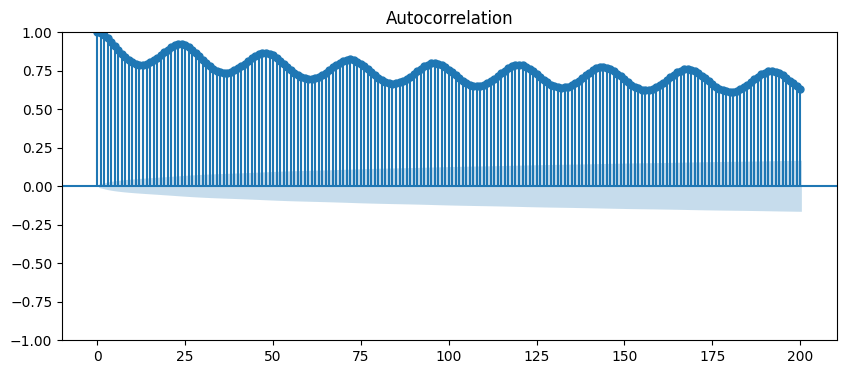

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(diagnostic_series, lags=200, ax=ax)
plt.show()

In [6]:
from statsmodels.tsa.stattools import adfuller

def run_adf(series, label):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'{label}')
    print(f'  ADF statistic: {result[0]:.4f}')
    print(f'  p-value:       {result[1]:.4f}')
    print(f'  # lags used:   {result[2]}')
    print(f'  # obs used:    {result[3]}')
    for pct, crit in result[4].items():
        print(f'  critical value ({pct}): {crit:.4f}')
    truth = True if result[1] < 0.05 else False
    print(f'  Stationary at 5%? {truth}')
    print()
    return result

adf_result = run_adf(diagnostic_series, 'Raw development target')

Raw development target
  ADF statistic: -6.2195
  p-value:       0.0000
  # lags used:   51
  # obs used:    31530
  critical value (1%): -3.4306
  critical value (5%): -2.8616
  critical value (10%): -2.5668
  Stationary at 5%? True



### Rolling mean and standard deviation


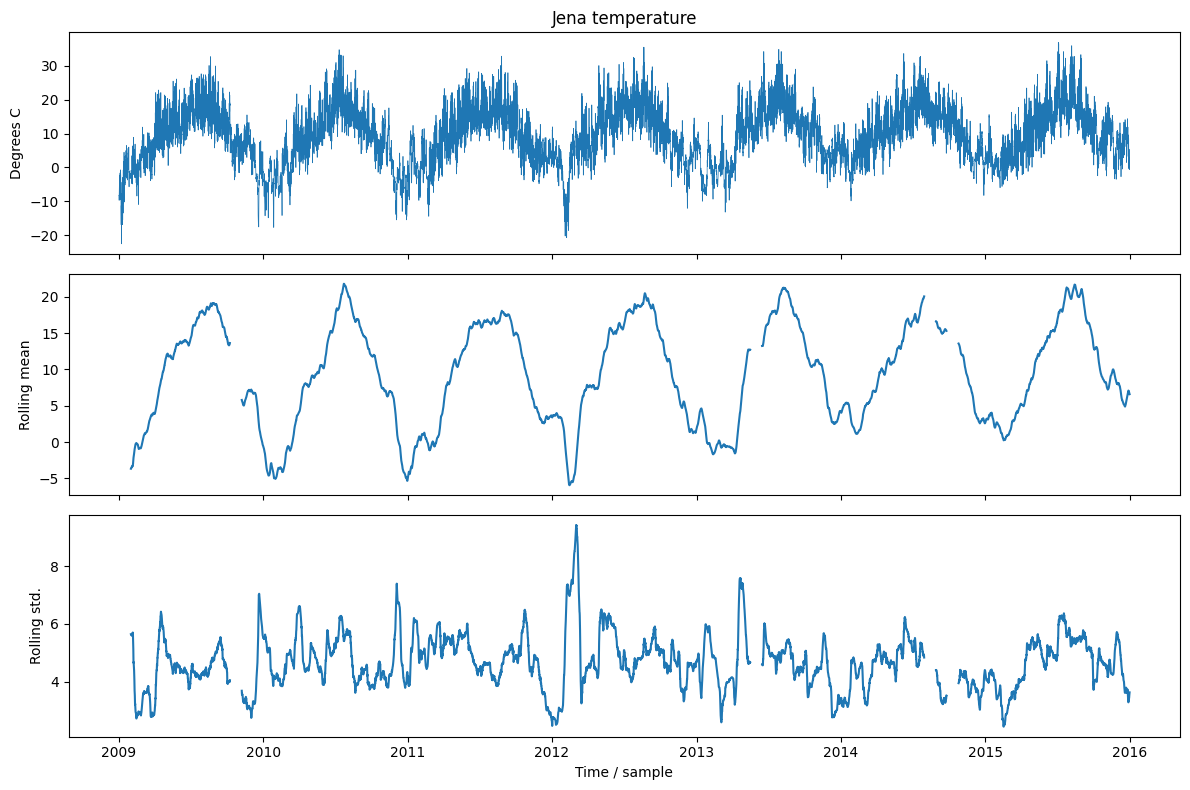

In [7]:
rolling = development.rolling(rolling_window, min_periods=rolling_window)
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(development, linewidth=0.5)
axes[0].set(title=dataset_name, ylabel=target_unit)
axes[1].plot(rolling.mean())
axes[1].set(ylabel='Rolling mean')
axes[2].plot(rolling.std())
axes[2].set(ylabel='Rolling std.', xlabel='Time / sample')
fig.tight_layout()
plt.show()

### Features and target


In [8]:
from sklearn.preprocessing import StandardScaler
from IPython.display import display

features = target.to_frame()
target_values = target.copy()
print('Input features:', features.columns.tolist())

Input features: ['T (degC)']


### Five separate chronological blocks

same splits

In [9]:
sequence_lengths = [3, 24, 168]

blocks = []
for positions in np.array_split(np.arange(test_start), 5):
    start, end = int(positions[0]), int(positions[-1] + 1)
    train_end = start + int(0.8 * (end - start))
    blocks.append((start, train_end, end))

display(pd.DataFrame([
    {'fold': i + 1, 'block_start': target.index[start],
     'early_stop_start': target.index[start + int(0.85 * (train_end - start))],
     'validation_start': target.index[train_end], 'block_end': target.index[end - 1]}
    for i, (start, train_end, end) in enumerate(blocks)
]))

,fold,block_start,early_stop_start,validation_start,block_end
0,1,2009-01-01 01:00:00,2009-12-14 15:00:00,2010-02-14 00:00:00,2010-05-27 05:00:00
1,2,2010-05-27 06:00:00,2011-05-09 20:00:00,2011-07-10 05:00:00,2011-10-20 10:00:00
2,3,2011-10-20 11:00:00,2012-10-02 01:00:00,2012-12-02 10:00:00,2013-03-14 15:00:00
3,4,2013-03-14 16:00:00,2014-02-25 05:00:00,2014-04-27 14:00:00,2014-08-07 19:00:00
4,5,2014-08-07 20:00:00,2015-07-21 09:00:00,2015-09-20 18:00:00,2015-12-31 23:00:00


## Pre-processing


In [10]:
def prepare_block(start, train_end, end, length):
    assert length in sequence_lengths
    fit_end = int(0.85 * (train_end - start))
    validation_start = train_end - start

    x = features.iloc[start:end].to_numpy()
    y = target_values.iloc[start:end].to_numpy()
    counts = target.iloc[start:end].to_numpy()

    longest = max(sequence_lengths)
    valid = np.array([
        t for t in range(longest, len(x))
        if np.isfinite(x[t-longest:t]).all() and np.isfinite(y[t])
    ], dtype=int)
    groups = {
        'train': valid[valid < fit_end],
        'stop': valid[(valid >= fit_end) & (valid < validation_start)],
        'validation': valid[valid >= validation_start]
    }
    assert all(len(ids) for ids in groups.values()), 'A split has no usable sequences.'

    x_scaler = StandardScaler().fit(x[:fit_end][np.isfinite(x[:fit_end]).all(axis=1)])
    y_scaler = StandardScaler().fit(y[groups['train'], None])
    x_scaled = x_scaler.transform(x)
    prepared = {}
    for name, ids in groups.items():
        prepared[name] = {
            'X': np.stack([x_scaled[t-length:t] for t in ids]).astype('float32'),
            'y': y_scaler.transform(y[ids, None]).astype('float32'),
            'last_value': counts[ids - 1],
            'actual': counts[ids],
            'dates': target.index[start + ids]
        }
    return prepared, x_scaler, y_scaler

### First block, 24-step sequences


In [11]:
fold_data, x_scaler, y_scaler = prepare_block(*blocks[0], length=24)
X_train, y_train = fold_data['train']['X'], fold_data['train']['y']
X_stop, y_stop = fold_data['stop']['X'], fold_data['stop']['y']
X_val, y_val = fold_data['validation']['X'], fold_data['validation']['y']

for name, part in fold_data.items():
    print(name, 'X:', part['X'].shape, 'y:', part['y'].shape)

fold_sizes = []
for i, block in enumerate(blocks, 1):
    prepared, _, _ = prepare_block(*block, length=24)
    fold_sizes.append({'fold': i, **{name: len(part['y']) for name, part in prepared.items()}})
display(pd.DataFrame(fold_sizes))

train X: (8005, 24, 1) y: (8005, 1)
stop X: (1473, 24, 1) y: (1473, 1)
validation X: (2454, 24, 1) y: (2454, 1)


,fold,train,stop,validation
0,1,8005,1473,2454
1,2,8174,1473,2454
2,3,8174,1473,2454
3,4,8004,1473,2285
4,5,7989,1473,2454


## Train Elman, Jordan and multi-recurrent RNNs on blocked CV5




In [12]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

test_preview, _, _ = prepare_block(0, test_start, len(target), length=24)
print('Final test slots:', len(target) - test_start)
print('Eligible final test targets:', len(test_preview['validation']['y']))
del test_preview

Final test slots: 8784
Eligible final test targets: 8541


In [13]:
class JordanCell(keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.state_size = 1
        self.output_size = units
        self.hidden = keras.layers.Dense(units, activation='tanh')
        self.readout = keras.layers.Dense(1)

    def build(self, input_shape):
        self.hidden.build((None, int(input_shape[-1]) + 1))
        self.readout.build((None, self.hidden.units))
        super().build(input_shape)

    def call(self, inputs, states, training=None):
        combined = tf.concat([inputs, states[0]], axis=-1)
        hidden = self.hidden(combined)
        output = self.readout(hidden)
        # Expose hidden for the final readout; feed back the undropped prediction.
        return hidden, [output]


class MultiRecurrentCell(keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.state_size = [units, 1]  # Previous hidden state and predicted output.
        self.output_size = units
        self.hidden = keras.layers.Dense(units, activation='tanh')
        self.readout = keras.layers.Dense(1)

    def build(self, input_shape):
        self.hidden.build((None, int(input_shape[-1]) + self.state_size[0] + 1))
        self.readout.build((None, self.state_size[0]))
        super().build(input_shape)

    def call(self, inputs, states, training=None):
        previous_hidden, previous_output = states
        combined = tf.concat([inputs, previous_hidden, previous_output], axis=-1)
        hidden = self.hidden(combined)
        output = self.readout(hidden)
        # Both feedback states are calculated before final-output dropout.
        return hidden, [hidden, output]


def build_rnn(name, length, units):
    inputs = keras.Input(shape=(length, features.shape[1]))
    if name == 'Jordan':
        cell = JordanCell(units)
        hidden = keras.layers.RNN(cell)(inputs)
    elif name == 'MultiRecurrent':
        cell = MultiRecurrentCell(units)
        hidden = keras.layers.RNN(cell)(inputs)
    elif name == 'Elman':
        cell = None
        hidden = keras.layers.SimpleRNN(units)(inputs)
    else:
        raise ValueError(name)
    hidden = keras.layers.Dropout(0.1)(hidden)
    output = (cell.readout(hidden) if cell is not None
              else keras.layers.Dense(1)(hidden))
    model = keras.Model(inputs, output, name=name)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005, clipnorm=2.0),
                  loss=keras.losses.Huber(3.0), metrics=['mae'])
    return model


### Fit one model and measure its errors


In [14]:
def predictions(model, part, scaler):
    prediction = scaler.inverse_transform(model.predict(part['X'], verbose=0)).ravel()
    return np.maximum(0, prediction) if nonnegative_target else prediction


def fit_rnn(name, data, scaler, length, units, max_epochs=60):
    keras.backend.clear_session()
    keras.utils.set_random_seed(11)
    model = build_rnn(name, length, units)
    stopping = keras.callbacks.EarlyStopping(
        monitor='val_mae', patience=5, restore_best_weights=True)
    history = model.fit(
        data['train']['X'], data['train']['y'],
        validation_data=(data['stop']['X'], data['stop']['y']),
        epochs=max_epochs, batch_size=64, shuffle=True, verbose=0,
        callbacks=[stopping, keras.callbacks.TerminateOnNaN()]
    ).history
    assert np.isfinite(history['val_mae']).all(), 'Training became unstable.'
    prediction = predictions(model, data['validation'], scaler)
    actual = data['validation']['actual']
    error = prediction - actual
    scores = {
        'MAE': np.mean(np.abs(error)),
        'RMSE': np.sqrt(np.mean(error**2)),
        'best_epoch': int(np.argmin(history['val_mae']) + 1),
        'epochs_run': len(history['mae']),
        'hit_epoch_limit': len(history['mae']) == max_epochs,
        'parameters': model.count_params()
    }
    for split in ['train', 'stop']:
        scores[split + '_MAE'] = np.mean(np.abs(
            predictions(model, data[split], scaler) - data[split]['actual']))

    history['mae_original_units'] = (np.array(history['mae']) * scaler.scale_[0]).tolist()
    history['val_mae_original_units'] = (np.array(history['val_mae']) * scaler.scale_[0]).tolist()
    return model, scores, history, prediction

In [15]:
def run_cv(configurations, name):
    rows, histories = [], {}
    for length, units in configurations:
        for fold, block in enumerate(blocks, 1):
            data, _, scaler = prepare_block(*block, length=length)
           
            print(f'{name}: length={length}, units={units}, fold={fold}/5', flush=True)
            _, scores, history, _ = fit_rnn(name, data, scaler, length, units)
            rows.append({'model': name, 'length': length, 'units': units,
                            'fold': fold, 'n_validation': len(data['validation']['y']), **scores})
            histories[(name, length, units, fold)] = history
            print(f"  MAE={scores['MAE']:.2f}, best epoch={scores['best_epoch']}", flush=True)
    
    return pd.DataFrame(rows), histories

def persistence_cv(blocks):
    """Prediction is simply target before time t - a passive model baseline effectively"""
    rows = []
    for fold, block in enumerate(blocks, 1):
        data, _, _ = prepare_block(*block, length=sequence_lengths[0])
        actual = data['validation']['actual']
        last_value = data['validation']['last_value']
        error = last_value - actual
        rows.append({
            'fold': fold,
            'n_validation': len(actual),
            'persistence_MAE': np.mean(np.abs(error)),
            'persistence_RMSE': np.sqrt(np.mean(error**2)),
            'validation_mean': np.mean(actual),
        })
    return pd.DataFrame(rows)

def persistence_comparison(cv_results, persistence_results):

    keys = ['model', 'length', 'units']
    expected_folds = set(persistence_results['fold'])
    for _, group in cv_results.groupby(keys):
        if (set(group['fold']) != expected_folds or group['fold'].duplicated().any()
                or not np.isfinite(group['MAE']).all()):
            raise ValueError('Each configuration must have one finite MAE per baseline fold.')
    ranking = (cv_results.groupby(keys, as_index=False)
               .agg(mean_CV_MAE=('MAE', 'mean'))
               .sort_values(['model', 'mean_CV_MAE', 'length', 'units']))
    best = ranking.drop_duplicates('model')
    selected = cv_results.merge(best, on=keys, validate='many_to_one')
    merged = selected.merge(persistence_results, on='fold',
                            suffixes=('', '_baseline'), validate='many_to_one')
    if not merged['n_validation'].eq(merged['n_validation_baseline']).all():
        raise ValueError('Recompute model and persistence results on the same validation targets.')
    merged['relative_MAE'] = merged['MAE'] / merged['validation_mean']
    merged['MASE_persistence'] = merged['MAE'] / merged['persistence_MAE']  # < 1 beats persistence
    merged['skill_vs_persistence'] = 1 - merged['MASE_persistence']  # > 0 beats persistence
    return merged.sort_values(['model', 'fold']).reset_index(drop=True)

persistence_results = persistence_cv(blocks)
display(persistence_results)

,fold,n_validation,persistence_MAE,persistence_RMSE,validation_mean
0,1,2454,0.701927,0.993980,6.473610
1,2,2454,0.816542,1.112379,15.144826
2,3,2454,0.359243,0.557030,0.415291
3,4,2285,0.841146,1.100358,16.429371
4,5,2454,0.586471,0.830351,8.012940


### Elman RNN

In [16]:
configurations = [(3, 32), (24, 32), (24, 64), (168, 32)]
cv_results1, cv_histories1 = run_cv(configurations, name='Elman')
configuration_means1 = (
    cv_results1.groupby(['length', 'units'])[['train_MAE', 'MAE']]
    .mean().reindex(pd.MultiIndex.from_tuples(configurations, names=['length', 'units']))
)
mae_train_mean = configuration_means1['train_MAE'].tolist()
mae_eval_mean = configuration_means1['MAE'].tolist()

Elman: length=3, units=32, fold=1/5

  MAE=0.47, best epoch=9
Elman: length=3, units=32, fold=2/5
  MAE=0.50, best epoch=11
Elman: length=3, units=32, fold=3/5
  MAE=0.35, best epoch=4
Elman: length=3, units=32, fold=4/5
  MAE=0.58, best epoch=4
Elman: length=3, units=32, fold=5/5
  MAE=0.40, best epoch=10
Elman: length=24, units=32, fold=1/5
  MAE=0.44, best epoch=9
Elman: length=24, units=32, fold=2/5
  MAE=0.48, best epoch=8
Elman: length=24, units=32, fold=3/5
  MAE=0.34, best epoch=4
Elman: length=24, units=32, fold=4/5
  MAE=0.53, best epoch=7
Elman: length=24, units=32, fold=5/5
  MAE=0.39, best epoch=7
Elman: length=24, units=64, fold=1/5
  MAE=0.43, best epoch=5
Elman: length=24, units=64, fold=2/5
  MAE=0.48, best epoch=12
Elman: length=24, units=64, fold=3/5
  MAE=0.30, best epoch=7
Elman: length=24, units=64, fold=4/5
  MAE=0.49, best epoch=4
Elman: length=24, units=64, fold=5/5
  MAE=0.39, best epoch=17
Elman: length=168, units=32, fold=1/5
  MAE=0.46, best epoch=6
Elman: 

In [17]:
comparison1 = persistence_comparison(cv_results1, persistence_results)
display(comparison1[['model', 'length', 'units', 'mean_CV_MAE', 'fold',
                       'MAE', 'persistence_MAE', 'RMSE', 'persistence_RMSE',
                       'MASE_persistence', 'skill_vs_persistence', 'relative_MAE']])

,model,length,units,mean_CV_MAE,fold,MAE,persistence_MAE,RMSE,persistence_RMSE,MASE_persistence,skill_vs_persistence,relative_MAE
0,Elman,24,64,0.419819,1,0.434767,0.701927,0.658276,0.993980,0.619390,0.380610,0.067160
1,Elman,24,64,0.419819,2,0.481051,0.816542,0.702641,1.112379,0.589131,0.410869,0.031763
2,Elman,24,64,0.419819,3,0.300406,0.359243,0.457168,0.557030,0.836221,0.163779,0.723363
3,Elman,24,64,0.419819,4,0.494019,0.841146,0.713252,1.100358,0.587316,0.412684,0.030069
4,Elman,24,64,0.419819,5,0.388853,0.586471,0.560765,0.830351,0.663039,0.336961,0.048528


In [18]:
print(np.mean(comparison1["MASE_persistence"]))

0.6590194349151974


### Jordan RNN

In [19]:
configurations = [(3, 32), (24, 32), (24, 64), (168, 32)]
cv_results2, cv_histories2 = run_cv(configurations, name='Jordan')
configuration_means2 = (
    cv_results2.groupby(['length', 'units'])[['train_MAE', 'MAE']]
    .mean().reindex(pd.MultiIndex.from_tuples(configurations, names=['length', 'units']))
)
mae_train_mean2 = configuration_means2['train_MAE'].tolist()
mae_eval_mean2 = configuration_means2['MAE'].tolist()

Jordan: length=3, units=32, fold=1/5
  MAE=0.62, best epoch=15
Jordan: length=3, units=32, fold=2/5
  MAE=0.71, best epoch=11
Jordan: length=3, units=32, fold=3/5
  MAE=0.33, best epoch=7
Jordan: length=3, units=32, fold=4/5
  MAE=0.75, best epoch=6
Jordan: length=3, units=32, fold=5/5
  MAE=0.52, best epoch=10
Jordan: length=24, units=32, fold=1/5
  MAE=0.55, best epoch=15
Jordan: length=24, units=32, fold=2/5
  MAE=0.62, best epoch=11
Jordan: length=24, units=32, fold=3/5
  MAE=0.32, best epoch=4
Jordan: length=24, units=32, fold=4/5
  MAE=0.66, best epoch=6
Jordan: length=24, units=32, fold=5/5
  MAE=0.46, best epoch=10
Jordan: length=24, units=64, fold=1/5
  MAE=0.54, best epoch=6
Jordan: length=24, units=64, fold=2/5
  MAE=0.61, best epoch=10
Jordan: length=24, units=64, fold=3/5
  MAE=0.30, best epoch=4
Jordan: length=24, units=64, fold=4/5
  MAE=0.64, best epoch=5
Jordan: length=24, units=64, fold=5/5
  MAE=0.46, best epoch=4
Jordan: length=168, units=32, fold=1/5
  MAE=0.55, be

In [20]:
comparison2 = persistence_comparison(cv_results2, persistence_results)
display(comparison2[['model', 'length', 'units', 'mean_CV_MAE', 'fold',
                       'MAE', 'persistence_MAE', 'RMSE', 'persistence_RMSE',
                       'MASE_persistence', 'skill_vs_persistence', 'relative_MAE']])

,model,length,units,mean_CV_MAE,fold,MAE,persistence_MAE,RMSE,persistence_RMSE,MASE_persistence,skill_vs_persistence,relative_MAE
0,Jordan,24,64,0.510417,1,0.539742,0.701927,0.790073,0.993980,0.768943,0.231057,0.083376
1,Jordan,24,64,0.510417,2,0.612421,0.816542,0.850920,1.112379,0.750017,0.249983,0.040438
2,Jordan,24,64,0.510417,3,0.304974,0.359243,0.477838,0.557030,0.848935,0.151065,0.734361
3,Jordan,24,64,0.510417,4,0.638177,0.841146,0.869046,1.100358,0.758700,0.241300,0.038844
4,Jordan,24,64,0.510417,5,0.456772,0.586471,0.649249,0.830351,0.778849,0.221151,0.057004


In [21]:
print(np.mean(comparison2["MASE_persistence"]))

0.7810885517453385


### MultiRecurrent RNN

In [22]:
configurations = [(3, 32), (24, 32), (24, 64), (168, 32)]

cv_results3, cv_histories3 = run_cv(configurations, name='MultiRecurrent')
configuration_means3 = (
    cv_results3.groupby(['length', 'units'])[['train_MAE', 'MAE']]
    .mean().reindex(pd.MultiIndex.from_tuples(configurations, names=['length', 'units']))
)
mae_train_mean3 = configuration_means3['train_MAE'].tolist()
mae_eval_mean3 = configuration_means3['MAE'].tolist()

MultiRecurrent: length=3, units=32, fold=1/5
  MAE=0.50, best epoch=4
MultiRecurrent: length=3, units=32, fold=2/5
  MAE=0.51, best epoch=11
MultiRecurrent: length=3, units=32, fold=3/5
  MAE=0.29, best epoch=16
MultiRecurrent: length=3, units=32, fold=4/5
  MAE=0.56, best epoch=10
MultiRecurrent: length=3, units=32, fold=5/5
  MAE=0.41, best epoch=9
MultiRecurrent: length=24, units=32, fold=1/5
  MAE=0.47, best epoch=9
MultiRecurrent: length=24, units=32, fold=2/5
  MAE=0.49, best epoch=8
MultiRecurrent: length=24, units=32, fold=3/5
  MAE=0.28, best epoch=10
MultiRecurrent: length=24, units=32, fold=4/5
  MAE=0.52, best epoch=11
MultiRecurrent: length=24, units=32, fold=5/5
  MAE=0.40, best epoch=5
MultiRecurrent: length=24, units=64, fold=1/5
  MAE=0.43, best epoch=6
MultiRecurrent: length=24, units=64, fold=2/5
  MAE=0.48, best epoch=10
MultiRecurrent: length=24, units=64, fold=3/5
  MAE=0.28, best epoch=14
MultiRecurrent: length=24, units=64, fold=4/5
  MAE=0.52, best epoch=5
Mult

In [23]:
comparison3 = persistence_comparison(cv_results3, persistence_results)
display(comparison3[['model', 'length', 'units', 'mean_CV_MAE', 'fold',
                       'MAE', 'persistence_MAE', 'RMSE', 'persistence_RMSE',
                       'MASE_persistence', 'skill_vs_persistence', 'relative_MAE']])

,model,length,units,mean_CV_MAE,fold,MAE,persistence_MAE,RMSE,persistence_RMSE,MASE_persistence,skill_vs_persistence,relative_MAE
0,MultiRecurrent,24,64,0.423684,1,0.434531,0.701927,0.666194,0.993980,0.619054,0.380946,0.067123
1,MultiRecurrent,24,64,0.423684,2,0.476677,0.816542,0.700176,1.112379,0.583775,0.416225,0.031475
2,MultiRecurrent,24,64,0.423684,3,0.282587,0.359243,0.453136,0.557030,0.786620,0.213380,0.680456
3,MultiRecurrent,24,64,0.423684,4,0.519657,0.841146,0.745211,1.100358,0.617796,0.382204,0.031630
4,MultiRecurrent,24,64,0.423684,5,0.404966,0.586471,0.568567,0.830351,0.690513,0.309487,0.050539


In [24]:
print(np.mean(comparison3["MASE_persistence"]))

0.6595516450490415


### Final chronological holdout


In [ ]:
cv_results_all = pd.concat([cv_results1, cv_results2, cv_results3], ignore_index=True)


best_configs = persistence_comparison(cv_results_all, persistence_results)[
    ['model', 'length', 'units']].drop_duplicates()

final_results = []
final_predictions = {}
for _, row in best_configs.iterrows():
    name, length, units = row['model'], int(row['length']), int(row['units'])
    final_data, _, y_scaler = prepare_block(0, test_start, len(target), length=length)
    model, scores, history, prediction = fit_rnn(name, final_data, y_scaler, length, units)
    final_results.append({'model': name, 'length': length, 'units': units, **scores})
    final_predictions[name] = {
        'dates': final_data['validation']['dates'],
        'actual': final_data['validation']['actual'],
        'prediction': prediction,
    }

final_results = pd.DataFrame(final_results)
assert len(final_results) == 3


last_key = 'last_count' if 'last_count' in final_data['train'] else 'last_value'
split_rows = []
for split in ['train', 'stop', 'validation']:
    actual = final_data[split]['actual']
    persistence_error = final_data[split][last_key] - actual
    split_rows.append({
        'split': 'test' if split == 'validation' else split,
        'n': len(actual),
        'target_mean': np.mean(actual),
        'target_SD': np.std(actual, ddof=1),
        'persistence_MAE': np.mean(np.abs(persistence_error)),
        'start': final_data[split]['dates'][0],
        'end': final_data[split]['dates'][-1],
    })

split_difficulty = pd.DataFrame(split_rows).set_index('split')
assert (final_data['train']['dates'][-1] < final_data['stop']['dates'][0]
        < final_data['validation']['dates'][0]), 'Chronological split overlap.'

final_results['train_MAE_over_persistence'] = (
    final_results['train_MAE'] / split_difficulty.loc['train', 'persistence_MAE'])
final_results['stop_MAE_over_persistence'] = (
    final_results['stop_MAE'] / split_difficulty.loc['stop', 'persistence_MAE'])
final_results['test_MAE_over_persistence'] = (
    final_results['MAE'] / split_difficulty.loc['test', 'persistence_MAE'])

display(split_difficulty)
display(final_results)


,n,target_mean,target_SD,persistence_MAE,start,end
split,,,,,,
train,51282,9.218011,8.502281,0.677606,2009-01-08 01:00:00,2014-12-13 13:00:00
stop,9202,10.173265,7.814714,0.694598,2014-12-13 14:00:00,2015-12-31 23:00:00
test,8541,10.041443,8.282579,0.660379,2016-01-01 00:00:00,2016-12-31 23:00:00


,model,length,units,MAE,RMSE,best_epoch,epochs_run,hit_epoch_limit,parameters,train_MAE,stop_MAE,train_MAE_over_persistence,stop_MAE_over_persistence,test_MAE_over_persistence
0,Elman,24,64,0.423832,0.624556,7,12,False,4289,0.435594,0.445201,0.642842,0.640947,0.641801
1,Jordan,24,64,0.513094,0.731865,1,6,False,257,0.525635,0.538452,0.775723,0.775199,0.776970
2,MultiRecurrent,24,64,0.416487,0.614182,4,9,False,4353,0.427942,0.437933,0.631551,0.630484,0.630678


## Final holdout predictions



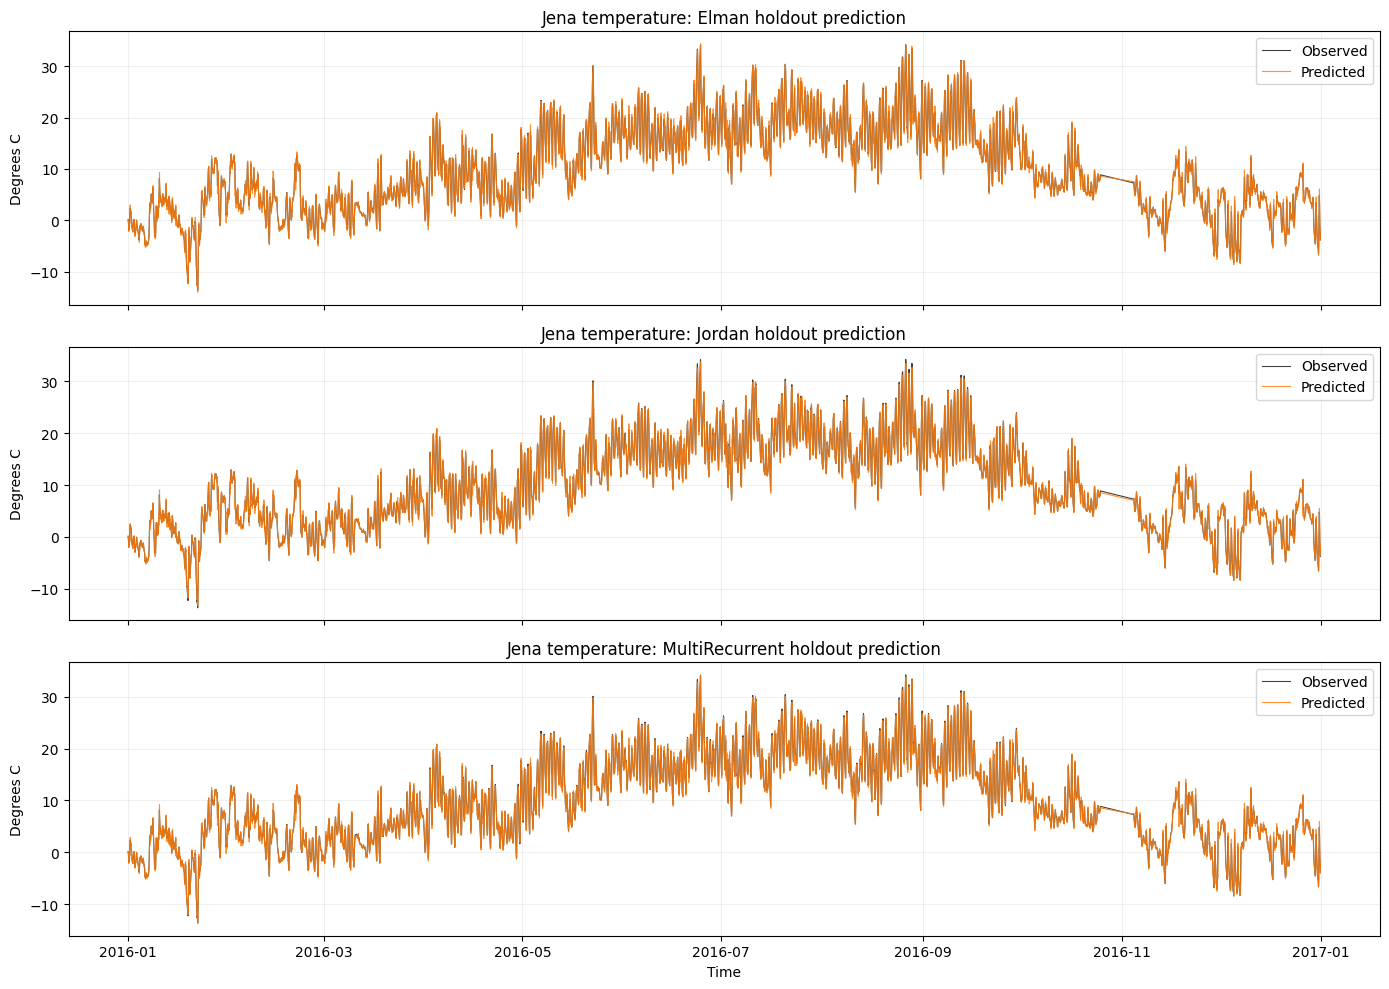

In [30]:
assert len(final_predictions) == 3

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, name in zip(axes, final_results['model']):
    record = final_predictions[name]
    ax.plot(record['dates'], record['actual'], color='black', linewidth=0.8,
            alpha=0.75, label='Observed')
    ax.plot(record['dates'], record['prediction'], color='tab:orange',
            linewidth=0.8, alpha=0.85, label='Predicted')
    ax.set_title(f'{dataset_name}: {name} holdout prediction')
    ax.set_ylabel(target_unit)
    ax.grid(alpha=0.2)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time' if not np.issubdtype(
    np.asarray(final_predictions[final_results.iloc[0]['model']]['dates']).dtype,
    np.number) else 'Sample')
fig.tight_layout()
plt.show()
